In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


sns.set_theme(style="darkgrid")

print("Ready")

Ready


In [2]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")

print("Loaded")

Loaded


In [3]:
df = orders.merge(customers,on="customer_id",how="left")

df = df.merge(
    items,
    on="order_id",
    how="left"
)

df = df.merge(
    products,
    on="product_id",
    how="left"
)

df = df.merge(
    sellers,
    on="seller_id",
    how="left"
)

df = df.merge(
    payments,
    on="order_id",
    how="left"
)

df = df.merge(
    reviews,
    on="order_id",
    how="left"
)

df = df.merge(
    category,
    on="product_category_name",
    how="left"
)


df.shape

(119143, 40)

In [4]:
df["revenue"] = (
    df["price"]
    +
    df["freight_value"]
)


df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)


df["order_month"] = (
    df["order_purchase_timestamp"]
    .dt
    .to_period("M")
)


df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,38.71,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,38.71,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares,38.71,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto,179.12,2018-08


In [5]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

df["order_delivered_customer_date"] = pd.to_datetime(
    df["order_delivered_customer_date"]
)

df["order_estimated_delivery_date"] = pd.to_datetime(
    df["order_estimated_delivery_date"]
)


df["delivery_days"] = (
    df["order_delivered_customer_date"]
    -
    df["order_purchase_timestamp"]
).dt.days


df["delivery_difference"] = (
    df["order_delivered_customer_date"]
    -
    df["order_estimated_delivery_date"]
).dt.days


def delivery_group(x):

    if x < 0:
        return "Early"

    elif x == 0:
        return "On Time"

    else:
        return "Late"


df["delivery_status"] = (
    df["delivery_difference"]
    .apply(delivery_group)
)


df[
    [
        "delivery_days",
        "delivery_status",
        "review_score"
    ]
].head()

,delivery_days,delivery_status,review_score
0,8.0,Early,4.0
1,8.0,Early,4.0
2,8.0,Early,4.0
3,13.0,Early,4.0
4,9.0,Early,5.0


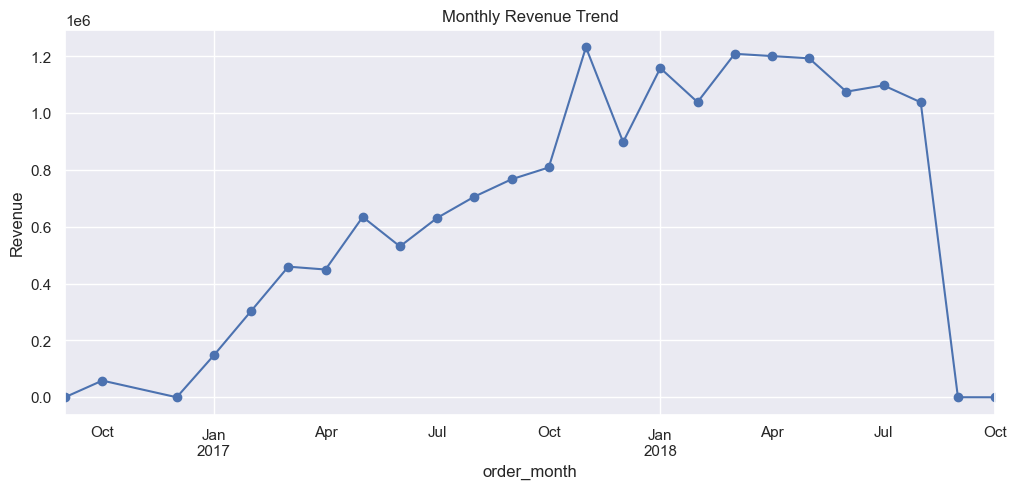

In [6]:
monthly = (
    df.groupby("order_month")["revenue"]
    .sum()
)

monthly.plot(
    figsize=(12,5),
    marker="o",
    title="Monthly Revenue Trend"
)

plt.ylabel("Revenue")

plt.show()

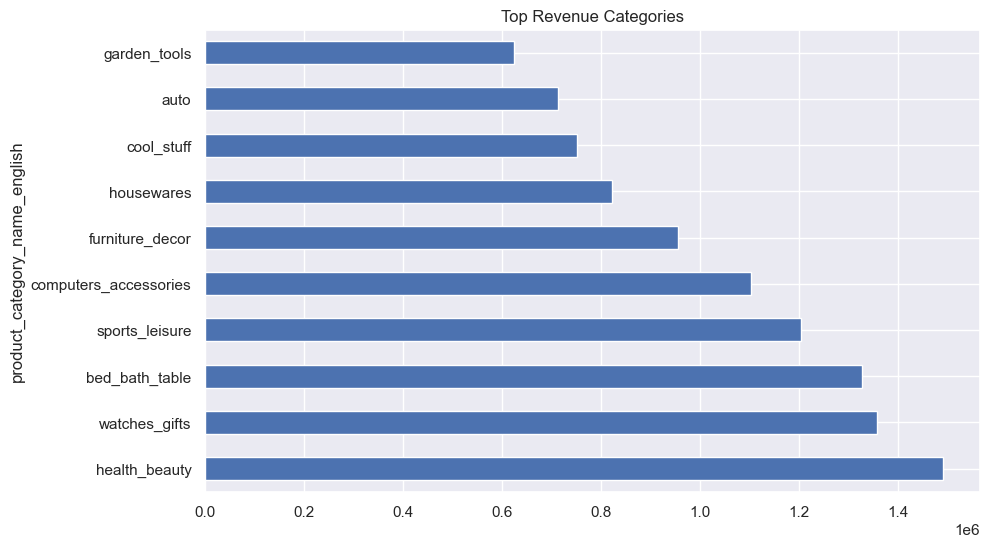

In [7]:
top_categories = (
    df.groupby(
        "product_category_name_english"
    )["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)


top_categories.plot(
    kind="barh",
    figsize=(10,6),
    title="Top Revenue Categories"
)


plt.show()

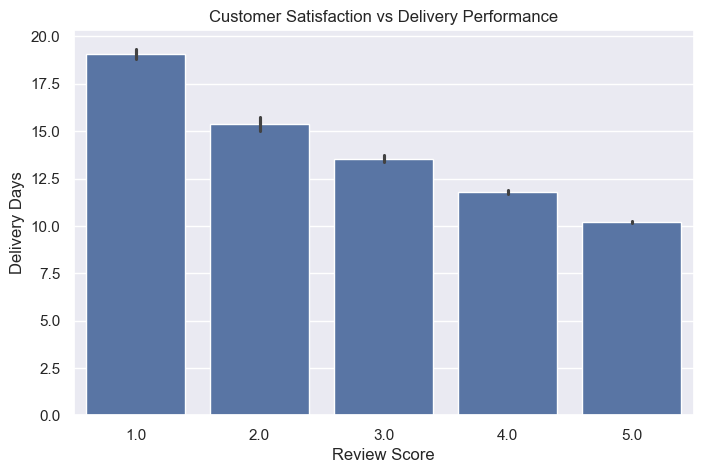

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="review_score",
    y="delivery_days"
)

plt.title("Customer Satisfaction vs Delivery Performance")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")

plt.show()

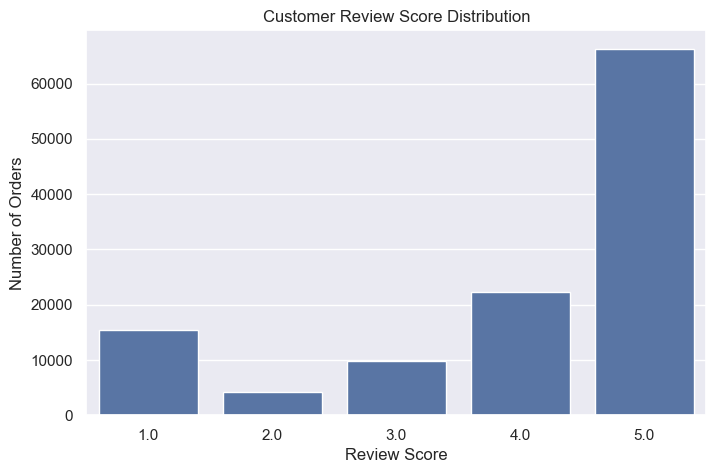

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="review_score"
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.show()

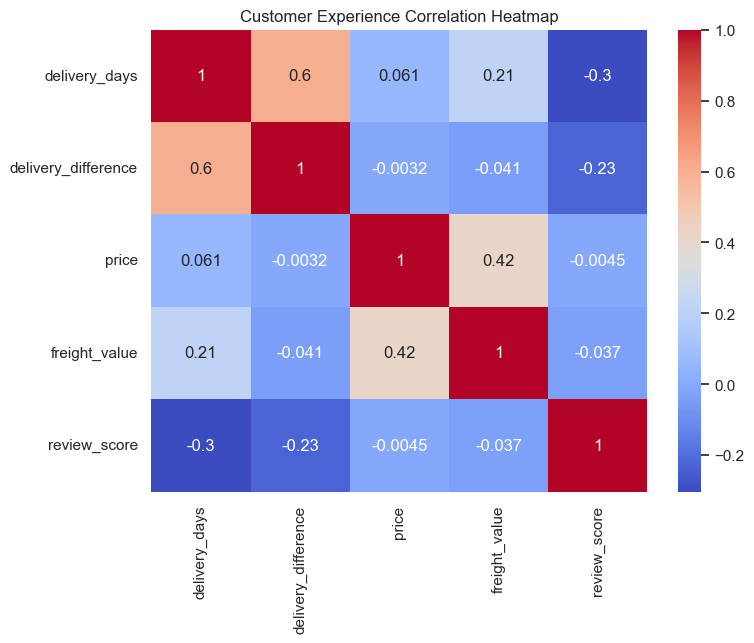

In [10]:
plt.figure(figsize=(8,6))

corr = df[
    [
        "delivery_days",
        "delivery_difference",
        "price",
        "freight_value",
        "review_score"
    ]
].corr()


sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Customer Experience Correlation Heatmap"
)

plt.show()

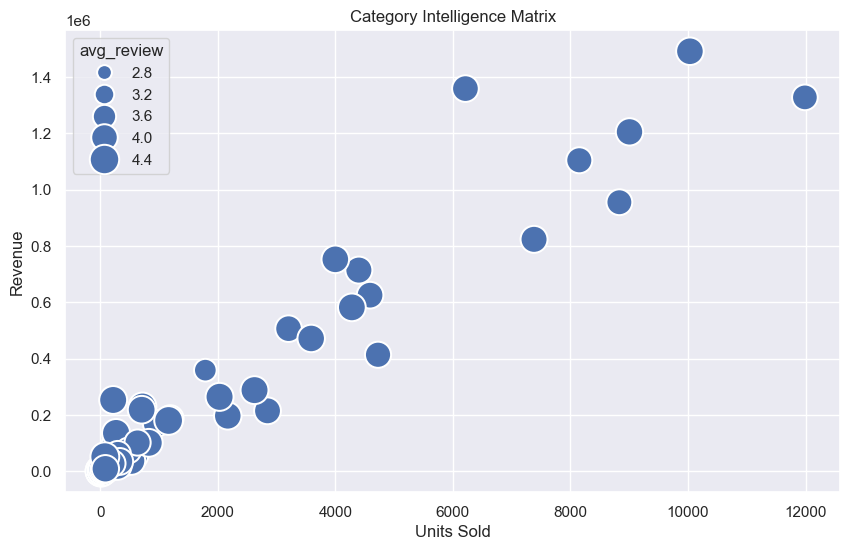

In [11]:
category_matrix = (
    df.groupby(
        "product_category_name_english"
    )
    .agg(
        revenue=("revenue","sum"),
        units_sold=("order_id","count"),
        avg_review=("review_score","mean")
    )
    .reset_index()
)


plt.figure(figsize=(10,6))


sns.scatterplot(
    data=category_matrix,
    x="units_sold",
    y="revenue",
    size="avg_review",
    sizes=(50,500)
)


plt.title(
    "Category Intelligence Matrix"
)

plt.xlabel(
    "Units Sold"
)

plt.ylabel(
    "Revenue"
)


plt.show()

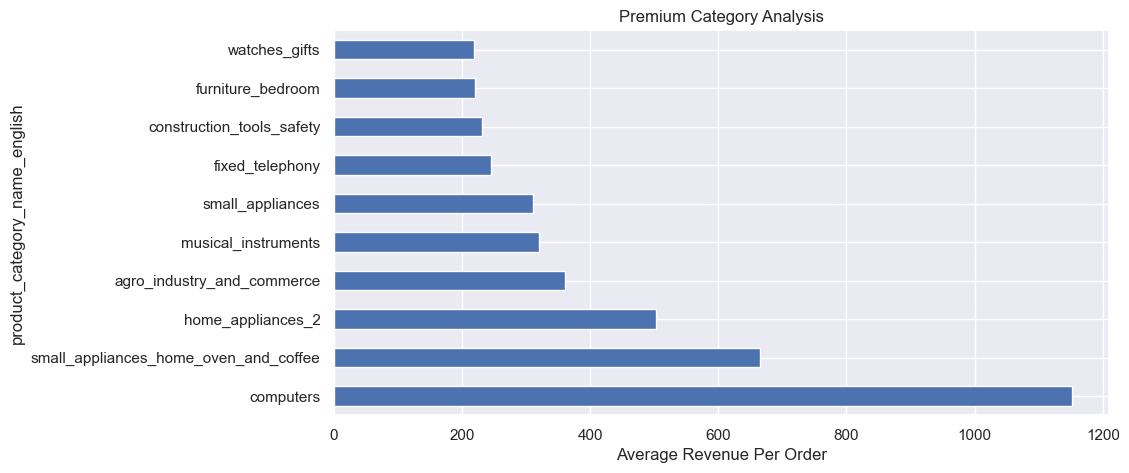

In [12]:
premium = (
    df.groupby(
        "product_category_name_english"
    )
    ["revenue"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(10,5))


premium.plot(
    kind="barh"
)


plt.title(
    "Premium Category Analysis"
)


plt.xlabel(
    "Average Revenue Per Order"
)


plt.show()

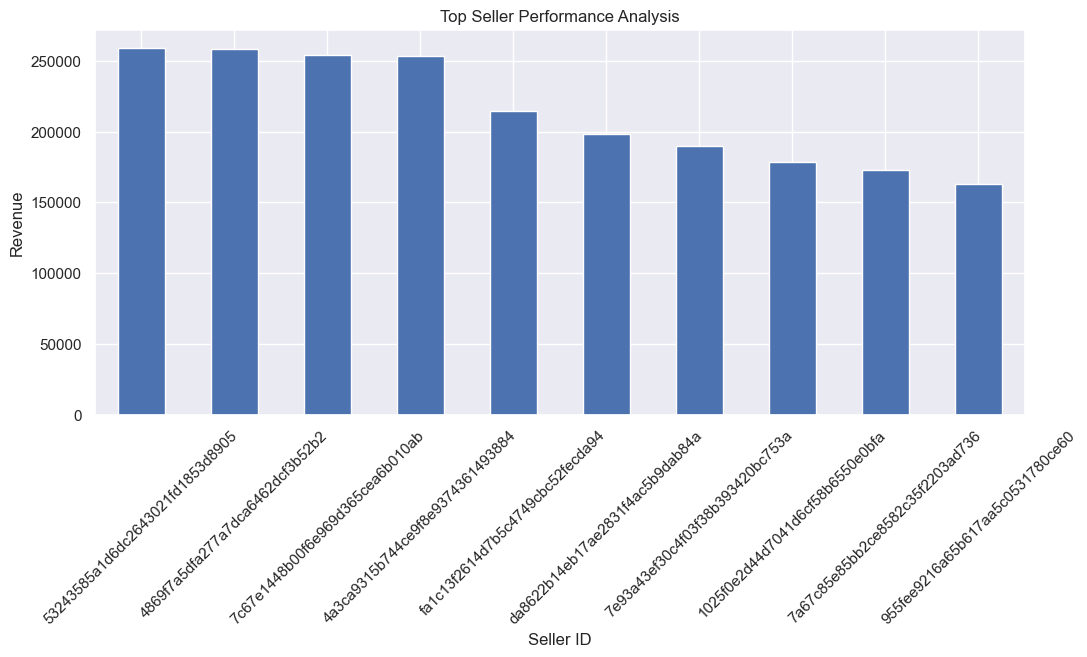

In [13]:
seller_revenue = (
    df.groupby("seller_id")
    ["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(12,5))

seller_revenue.plot(
    kind="bar"
)

plt.title(
    "Top Seller Performance Analysis"
)

plt.ylabel(
    "Revenue"
)

plt.xlabel(
    "Seller ID"
)

plt.xticks(rotation=45)

plt.show()

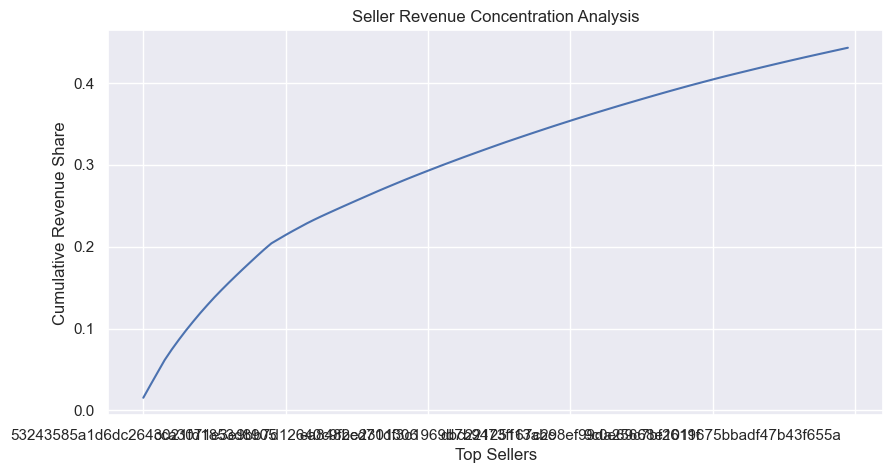

In [14]:
seller_share = (
    df.groupby("seller_id")
    ["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)


seller_share = (
    seller_share.cumsum()
    /
    seller_share.sum()
)


plt.figure(figsize=(10,5))

seller_share.head(100).plot()

plt.title(
    "Seller Revenue Concentration Analysis"
)

plt.xlabel(
    "Top Sellers"
)

plt.ylabel(
    "Cumulative Revenue Share"
)

plt.show()

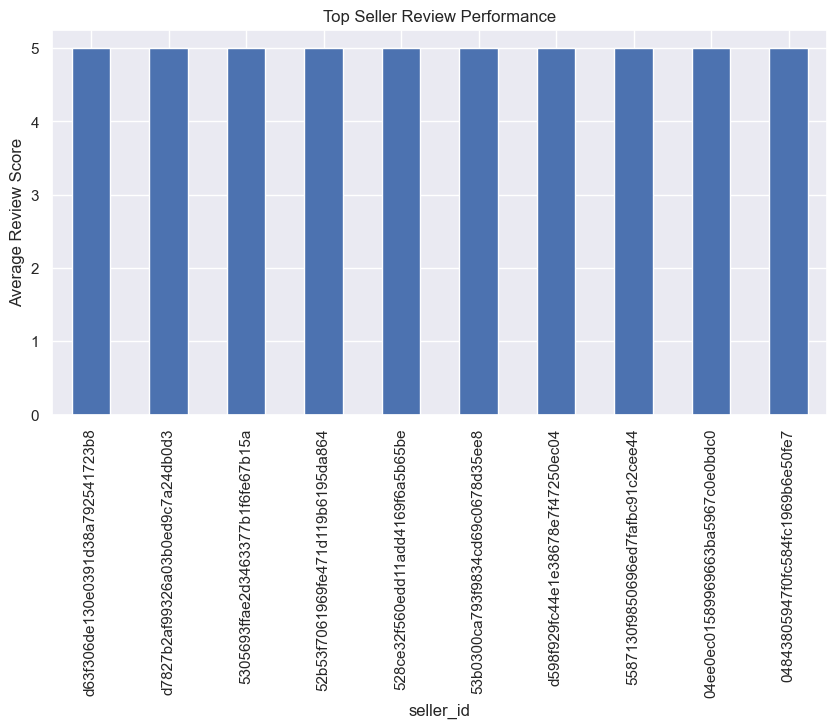

In [15]:
seller_review = (
    df.groupby("seller_id")
    ["review_score"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(10,5))


seller_review.plot(
    kind="bar"
)


plt.title(
    "Top Seller Review Performance"
)


plt.ylabel(
    "Average Review Score"
)


plt.show()

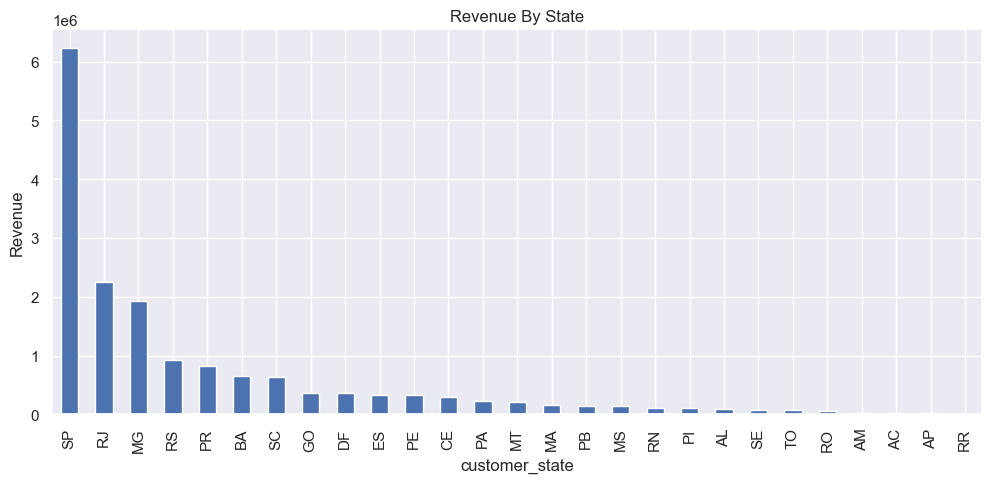

In [16]:
state_revenue = (
    df.groupby("customer_state")
    ["revenue"]
    .sum()
    .sort_values(
        ascending=False
    )
)


plt.figure(figsize=(12,5))

state_revenue.plot(
    kind="bar"
)


plt.title(
    "Revenue By State"
)


plt.ylabel(
    "Revenue"
)


plt.show()

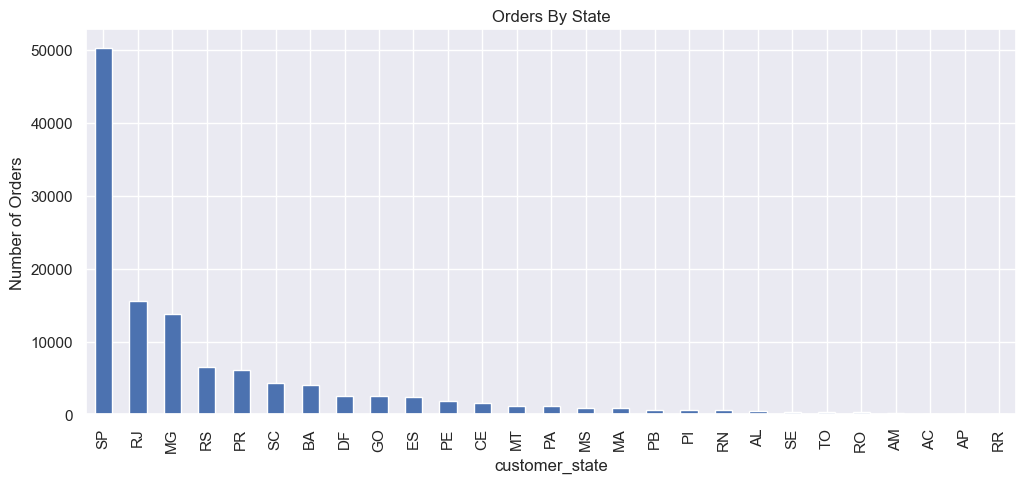

In [17]:
state_orders = (
    df.groupby("customer_state")
    ["order_id"]
    .count()
    .sort_values(
        ascending=False
    )
)


plt.figure(figsize=(12,5))


state_orders.plot(
    kind="bar"
)


plt.title(
    "Orders By State"
)


plt.ylabel(
    "Number of Orders"
)


plt.show()

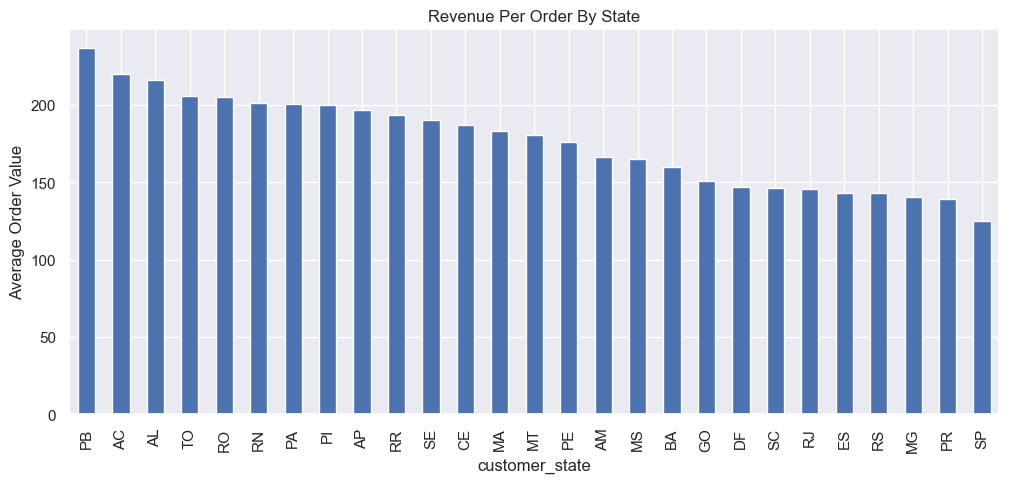

In [18]:
state_aov = (
    df.groupby("customer_state")
    ["revenue"]
    .mean()
    .sort_values(
        ascending=False
    )
)


plt.figure(figsize=(12,5))


state_aov.plot(
    kind="bar"
)


plt.title(
    "Revenue Per Order By State"
)


plt.ylabel(
    "Average Order Value"
)


plt.show()

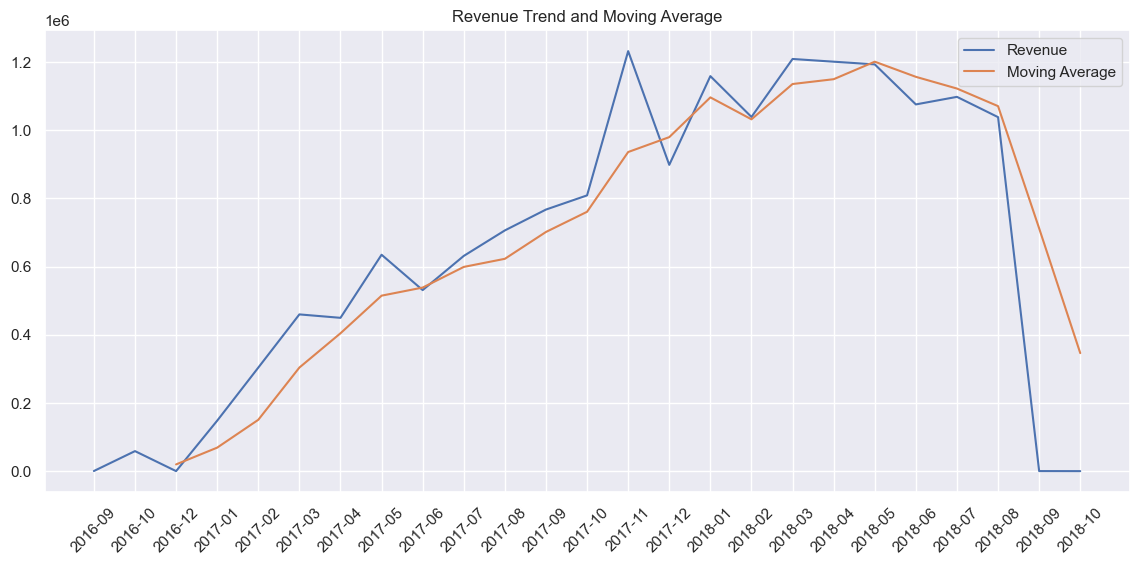

In [19]:
monthly_revenue = (
    df.groupby("order_month")
    ["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_month"]
    .astype(str)
)


monthly_revenue["moving_average"] = (
    monthly_revenue["revenue"]
    .rolling(3)
    .mean()
)


plt.figure(figsize=(14,6))


plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["revenue"],
    label="Revenue"
)


plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["moving_average"],
    label="Moving Average"
)


plt.xticks(rotation=45)

plt.title(
    "Revenue Trend and Moving Average"
)

plt.legend()

plt.show()

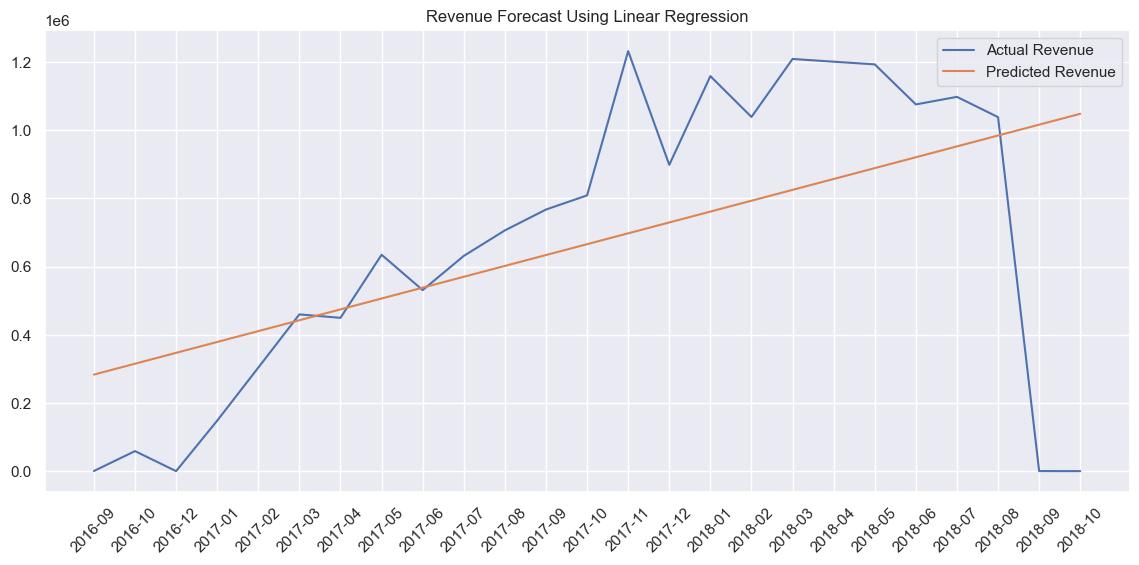

In [20]:
from sklearn.linear_model import LinearRegression


forecast_df = monthly_revenue.copy()


forecast_df["time_index"] = range(
    len(forecast_df)
)


X = forecast_df[
    ["time_index"]
]


y = forecast_df[
    "revenue"
]


model = LinearRegression()


model.fit(
    X,
    y
)


forecast_df["prediction"] = (
    model.predict(X)
)



plt.figure(figsize=(14,6))


plt.plot(
    forecast_df["order_month"],
    forecast_df["revenue"],
    label="Actual Revenue"
)


plt.plot(
    forecast_df["order_month"],
    forecast_df["prediction"],
    label="Predicted Revenue"
)


plt.xticks(rotation=45)


plt.title(
    "Revenue Forecast Using Linear Regression"
)


plt.legend()


plt.show()

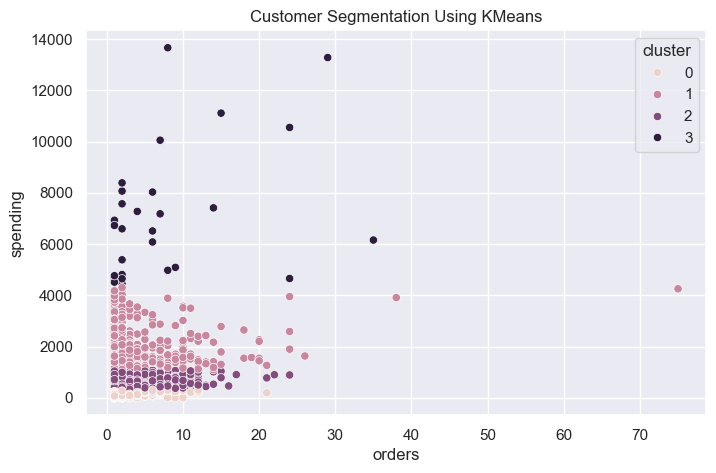

In [21]:
from sklearn.cluster import KMeans


customer_seg = (
    df.groupby("customer_unique_id")
    .agg(
        orders=("order_id","count"),
        spending=("revenue","sum")
    )
)


kmeans = KMeans(
    n_clusters=4,
    random_state=42
)


customer_seg["cluster"] = (
    kmeans.fit_predict(
        customer_seg
    )
)


plt.figure(figsize=(8,5))


sns.scatterplot(
    data=customer_seg,
    x="orders",
    y="spending",
    hue="cluster"
)


plt.title(
    "Customer Segmentation Using KMeans"
)


plt.show()

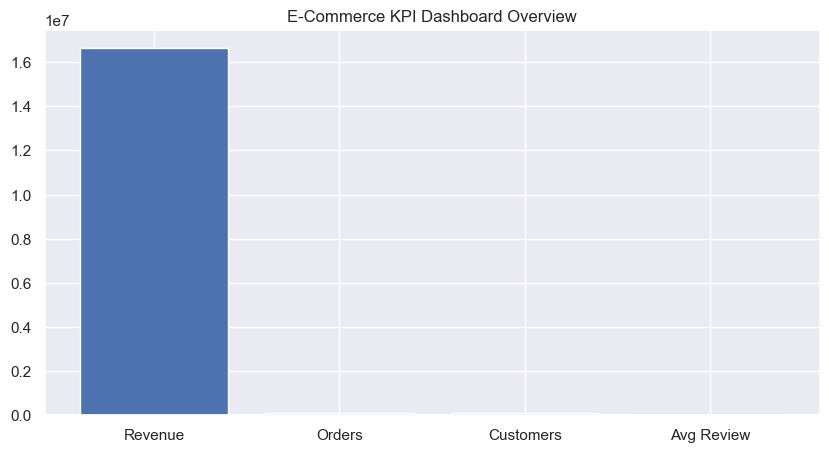

In [22]:
kpis = {
    "Revenue":df["revenue"].sum(),
    "Orders":df["order_id"].nunique(),
    "Customers":df["customer_unique_id"].nunique(),
    "Avg Review":df["review_score"].mean()
}


plt.figure(figsize=(10,5))


plt.bar(
    kpis.keys(),
    kpis.values()
)


plt.title(
    "E-Commerce KPI Dashboard Overview"
)


plt.show()

In [23]:
df.to_csv(
    "ecommerce_cleaned_data.csv",
    index=False
)

print("Cleaned dataset saved")

Cleaned dataset saved
